In [20]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from tree_sitter_languages import get_parser
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
from tree_sitter_languages import get_language, get_parser


#### Load Dataset

In [21]:
train_df = pd.read_parquet("../data/task_a/train.parquet")
val_df   = pd.read_parquet("../data/task_a/val.parquet")
test_df  = pd.read_parquet("../data/task_a/test_sample.parquet")

print(train_df.shape, val_df.shape, test_df.shape)

(500000, 4) (100000, 4) (1000, 4)


#### Tree-Sitter Setup

In [22]:

parsers = {
    "Python": get_parser("python"),
    "Java": get_parser("java"),
    "C++": get_parser("cpp")
}

c:\Users\yoges\OneDrive\Desktop\inlp project\machine-generated-code-detection\.venv\lib\site-packages\tree_sitter\__init__.py:36: FutureWarning: Language(path, name) is deprecated. Use Language(ptr, name) instead.
  warn("{} is deprecated. Use {} instead.".format(old, new), FutureWarning)


#### AST Path Extraction Function

In [ ]:
def extract_ast_paths(code, language):

    parser = parsers.get(language)

    if parser is None:
        return ""

    try:
        tree = parser.parse(bytes(code, "utf8"))
        root = tree.root_node
    except:
        return ""

    paths = []

    stack = [(root, None)]

    while stack:

        node, parent = stack.pop()

        if parent is not None:
            paths.append(parent + "->" + node.type)

        for child in node.children:
            stack.append((child, node.type))

    return " ".join(paths)

#### Parallel AST Path Extraction

In [ ]:
def parallel_ast_paths(df, max_workers=12):

    codes = df["code"].tolist()
    langs = df["language"].tolist()

    tasks = list(zip(codes, langs))

    docs = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:

        for doc in tqdm(
            executor.map(lambda x: extract_ast_paths(x[0], x[1]), tasks),
            total=len(tasks)
        ):
            docs.append(doc)

    return docs

In [ ]:
train_docs = parallel_ast_paths(train_df)

val_docs   = parallel_ast_paths(val_df)

test_docs  = parallel_ast_paths(test_df)

100%|██████████| 1000/1000 [00:00<00:00, 3011.59it/s]


In [ ]:
np.save("../data/train_docs.npy", np.array(train_docs, dtype=object))
np.save("../data/val_docs.npy",   np.array(val_docs, dtype=object))
np.save("../data/test_docs.npy",  np.array(test_docs, dtype=object))

In [ ]:
train_docs = np.load("../data/train_docs.npy", allow_pickle=True)
val_docs   = np.load("../data/val_docs.npy", allow_pickle=True)
test_docs  = np.load("../data/test_docs.npy", allow_pickle=True)

#### TF-IDF Vectorization

In [26]:
vectorizer = TfidfVectorizer(
    max_features=2000,
    token_pattern=r"[^ ]+",
    min_df=5
)

X_train = vectorizer.fit_transform(train_docs)
X_val   = vectorizer.transform(val_docs)
X_test  = vectorizer.transform(test_docs)

In [27]:
y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

## Train Models

### Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### SVM

In [30]:

svm_model = LinearSVC(
    class_weight="balanced",
    max_iter=5000
)

svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


#### CatBoost

In [31]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    verbose=100
)

cat_model.fit(X_train, y_train)

0:	learn: 0.5275061	total: 532ms	remaining: 2m 39s
100:	learn: 0.1516455	total: 32.4s	remaining: 1m 3s
200:	learn: 0.1333262	total: 1m 3s	remaining: 31.1s
299:	learn: 0.1244343	total: 1m 32s	remaining: 0us


CatBoostClassifier(depth=6, iterations=300, learning_rate=0.1, verbose=100)

#### Evaluation Function

In [32]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report
)

def evaluate_model(model, X, y, name):

    preds = model.predict(X)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)[:,1]
    else:
        probs = model.decision_function(X)

    print("\n======", name, "======")

    print("Accuracy:", accuracy_score(y, preds))
    print("Binary F1:", f1_score(y, preds))
    print("Macro F1:", f1_score(y, preds, average="macro"))
    print("Macro Precision:", precision_score(y, preds, average="macro"))
    print("Macro Recall:", recall_score(y, preds, average="macro"))
    print("ROC AUC:", roc_auc_score(y, probs))

    print("\nClassification Report")
    print(classification_report(y, preds))

    return probs

#### Evaluation on Validation

In [33]:
rf_val_probs  = evaluate_model(rf_model,  X_val, y_val, "Random Forest (VAL)")
svm_val_probs = evaluate_model(svm_model, X_val, y_val, "SVM (VAL)")
cat_val_probs = evaluate_model(cat_model, X_val, y_val, "CatBoost (VAL)")


====== Random Forest (VAL) ======
Accuracy: 0.93497
Binary F1: 0.9358444402789973
Macro F1: 0.9349579166833919
Macro Precision: 0.9355588617015019
Macro Recall: 0.9363315581907827
ROC AUC: 0.9820146016515758

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     47695
           1       0.97      0.91      0.94     52305

    accuracy                           0.93    100000
   macro avg       0.94      0.94      0.93    100000
weighted avg       0.94      0.93      0.93    100000


====== SVM (VAL) ======
Accuracy: 0.93196
Binary F1: 0.9322297256917469
Macro F1: 0.9319589222021113
Macro Precision: 0.9334696778281617
Macro Recall: 0.933760960130078
ROC AUC: 0.9815196441629717

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     47695
           1       0.97      0.89      0.93     52305

    accuracy                           0.93    100000
  

#### Evaluation on Test

In [34]:
rf_test_probs  = evaluate_model(rf_model,  X_test, y_test, "Random Forest (TEST)")
svm_test_probs = evaluate_model(svm_model, X_test, y_test, "SVM (TEST)")
cat_test_probs = evaluate_model(cat_model, X_test, y_test, "CatBoost (TEST)")


====== Random Forest (TEST) ======
Accuracy: 0.341
Binary F1: 0.3681687440076702
Macro F1: 0.3397792518366459
Macro Precision: 0.5309620596205962
Macro Recall: 0.5263748694241968
ROC AUC: 0.6556405861338598

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.19      0.31       777
           1       0.23      0.86      0.37       223

    accuracy                           0.34      1000
   macro avg       0.53      0.53      0.34      1000
weighted avg       0.70      0.34      0.32      1000


====== SVM (TEST) ======
Accuracy: 0.424
Binary F1: 0.3885350318471338
Macro F1: 0.4220557956967238
Macro Precision: 0.5560857062250357
Macro Recall: 0.5653975564289466
ROC AUC: 0.607017331232578

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.31      0.46       777
           1       0.25      0.82      0.39       223

    accuracy                           0.42      1000
   m

#### ROC Curve

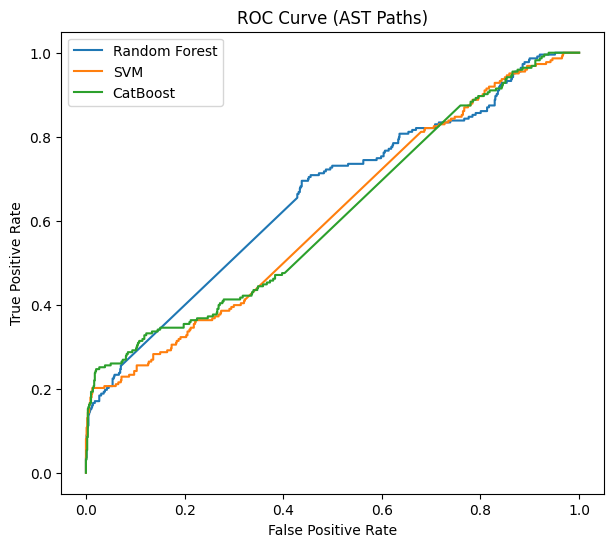

In [35]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_test_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_test_probs)
fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_test_probs)

plt.figure(figsize=(7,6))

plt.plot(fpr_rf,  tpr_rf,  label="Random Forest")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot(fpr_cat, tpr_cat, label="CatBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AST Paths)")

plt.legend()

plt.savefig("../data/roc_curve_ast_paths.png")

plt.show()

#### Interpret TF-IDF Features

In [36]:
importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1][:20]

top_features = [vectorizer.get_feature_names_out()[i] for i in indices]

for f,i in zip(top_features, importances[indices]):
    print(f"{f} : {i:.4f}")

error->identifier : 0.0547
expression_statement->identifier : 0.0510
pattern_list->, : 0.0409
module->error : 0.0403
pattern_list->identifier : 0.0378
tuple_pattern->, : 0.0342
tuple_pattern->( : 0.0339
module->comment : 0.0339
assignment->pattern_list : 0.0323
assignment->tuple_pattern : 0.0297
tuple_pattern->) : 0.0262
tuple_pattern->identifier : 0.0237
block->comment : 0.0207
error->error : 0.0135
error->: : 0.0130
error->. : 0.0130
module->function_definition : 0.0129
error->, : 0.0107
error->string_start : 0.0094
error->= : 0.0086


#### saving Results Table

In [37]:
results = []

for name, model in [
    ("Random Forest", rf_model),
    ("SVM", svm_model),
    ("CatBoost", cat_model)
]:

    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Macro F1": f1_score(y_test, preds, average="macro")
    })

pd.DataFrame(results)

,Model,Accuracy,Macro F1
0,Random Forest,0.341,0.339779
1,SVM,0.424,0.422056
2,CatBoost,0.579,0.512641


- While the AST path model achieves strong performance on the validation set (F1 ≈ 0.91), its performance drops significantly on the test set (F1 ≈ 0.35 for the AI class).
- This indicates that the learned structural patterns do not generalize well to unseen code generators. The model appears to capture generator-specific syntactic patterns rather than universal characteristics of machine-generated code.
- This result highlights a key challenge in AI code detection: models that perform well on in-distribution data may fail when evaluated on code produced by new or unseen language models.